<a href="https://colab.research.google.com/github/q1mora/cnt-property-prediction-using-ml-architectures/blob/ml/xgboost_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import torch
import torch.nn as nn
import seaborn as sns
import time


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
# configuration
batch_size = 32

seed = 43
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
# loading data
data = pd.read_csv("/content/CNT_Chiral_Index.csv")

df_0 = data[data["Metal (1) or Semi (0)"] == 0]
df_1 = data[data["Metal (1) or Semi (0)"] == 1]

# undersample class 1 to match class 0 size
df_0_under = df_0.sample(len(df_1), random_state=seed)

# balanced dataset
data = pd.concat([df_1, df_0_under]).sample(frac=1, random_state=seed)

# selecting features and target
features = ['n', 'm', 'diameter (A)', 'chiral angle (deg.)']
target = 'peakposition from Fermi level (eV)'

X = data[features].values
y = data[target].values.reshape(-1, 1)

In [ ]:
# train, test and split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed)

# scaling features
scaler = StandardScaler().fit(X_train)
x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [ ]:
start_time = time.time()

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=1e-3,
    batch_size=batch_size,
    max_depth=5,
    use_label_encoder=False,
    random_state=seed,
    eval_metrics="logloss"
)

eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# extract evaluation results
results = model.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

train_time = time.time() - start_time

# predictions
test_start = time.time()

y_pred_cont = model.predict(X_test)  # probabilities
# y_pred_class = (y_pred_cont >= 0.5).astype(int) # This line is no longer relevant for regression, but keeping it commented out for context if classification was intended later.

test_time = time.time() - test_start
total_time = train_time + test_time

# time summary
print("\ntime summary")
print(f"training time:        {train_time:.1f} seconds")
print(f"total runtime:         {total_time:.1f} seconds")
print(f"total train + start time: {total_time:.1f} seconds")


time summary
training time:        0.2 seconds
total runtime:         0.2 seconds
total train + start time: 0.2 seconds


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:28:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "batch_size", "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# evaluation
mse = mean_squared_error(y_test, y_pred_cont)
mae = mean_absolute_error(y_test, y_pred_cont)
r2 = r2_score(y_test, y_pred_cont)

print("test performance")
print(f"mse: {mse:.6f}")
print(f"mae: {mae:.6f}")
print(f"r2 score: {r2:.6f}")

test performance
mse: 0.123935
mae: 0.216559
r2 score: 0.327229


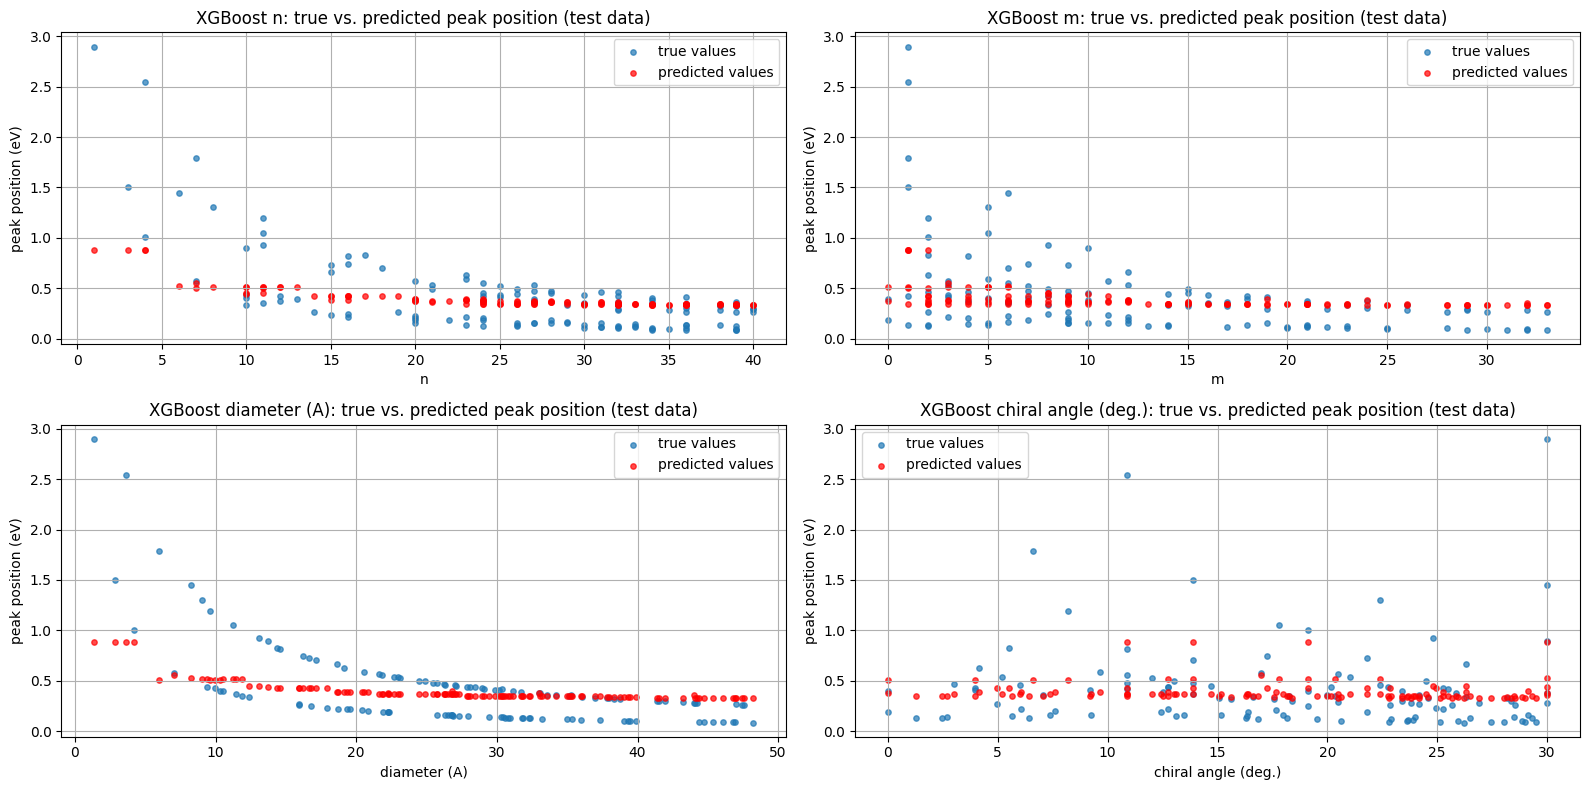

In [ ]:
num_features = len(features)
plt.figure(figsize=(16, 4 * ((num_features + 1) // 2))) # adjust figure height dynamically

for i, feature_name in enumerate(features):
    plt.subplot((num_features + 1) // 2, 2, i + 1) # create 2 columns for subplots
    plt.scatter(X_test[:, i], y_test, s=15, alpha=0.7, label='true values')
    plt.scatter(X_test[:, i], y_pred_cont, s=15, alpha=0.7, color='red', label='predicted values')
    plt.xlabel(feature_name)
    plt.ylabel('peak position (eV)')
    plt.title(f'XGBoost {feature_name}: true vs. predicted peak position (test data)')
    plt.grid(True)
    plt.legend()

plt.savefig('features_scatter_plot')
plt.tight_layout()
plt.show()

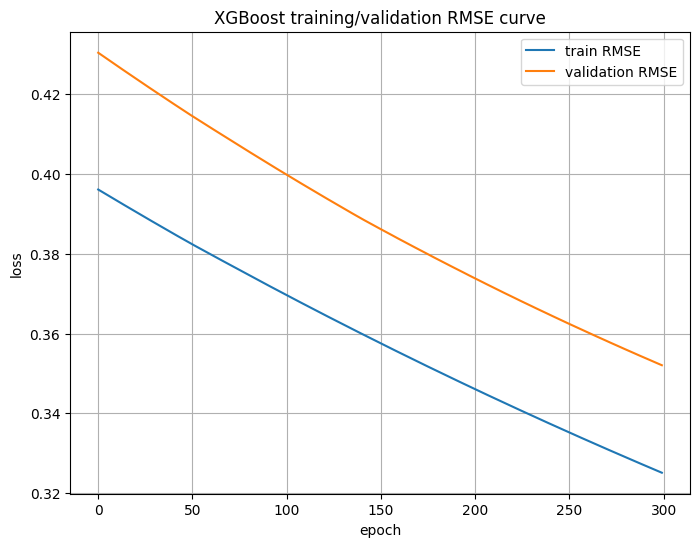

In [ ]:
# plotting training loss curve
plt.figure(figsize=(8, 6))

plt.plot(train_rmse, label="train RMSE")
plt.plot(val_rmse, label="validation RMSE")


plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("XGBoost training/validation RMSE curve")
plt.grid(True)
plt.legend()
plt.savefig('validation_training_loss_curve_option1')
plt.show()

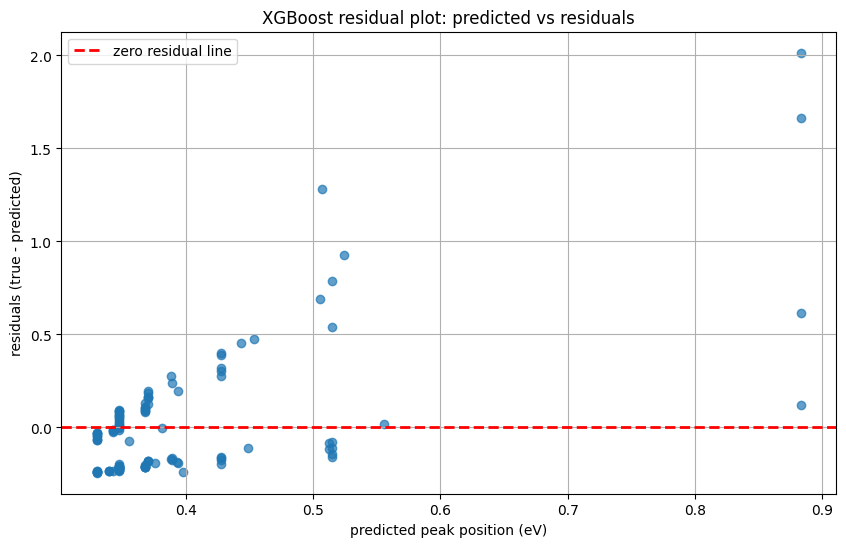

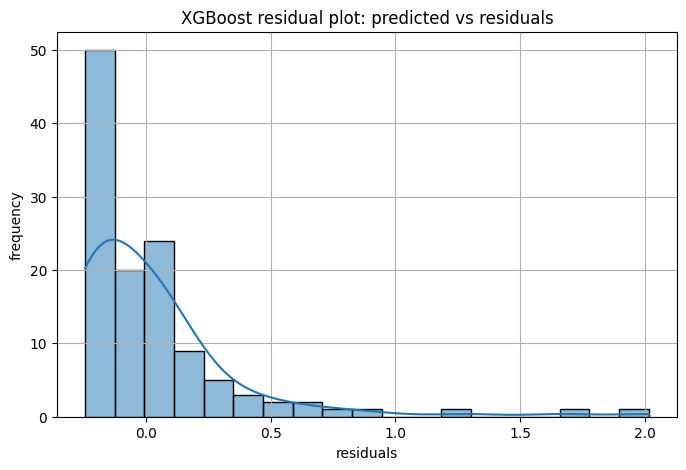

In [ ]:
# calculate residuals
residuals = y_test.flatten() - y_pred_cont

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_cont, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='zero residual line')
plt.xlabel('predicted peak position (eV)')
plt.ylabel('residuals (true - predicted)')
plt.title('XGBoost residual plot: predicted vs residuals')
plt.grid(True)
plt.savefig("XGBoost 'n' and 'm' residual plot")
plt.legend()
plt.show()

# helpful to see the distribution of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title('XGBoost residual plot: predicted vs residuals')
plt.xlabel('residuals')
plt.ylabel('frequency')
plt.savefig('XGBoost distribution of residuals')
plt.grid(True)
plt.show()